# The Wavenet

## The Intials

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
words = open("names.txt", 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
char = sorted(list(set(''.join(words))))
stoi = { x:i+1 for i, x in enumerate(char)}
stoi['.'] = 0
itos = {x:i for i,x in stoi.items()}
print(stoi)
itos
vocab_size = len(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [4]:
block_size = 3

def build_dataset(words):
    X, Y  = [], []
    for w in words:
        ch = w+'.'
        context = [0] *block_size
        # print(ch)
        for i in ch:
            # print(i)
            ix = stoi[i]
            # print(ix)
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X= torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182485, 3]) torch.Size([182485])
torch.Size([22822, 3]) torch.Size([22822])
torch.Size([22846, 3]) torch.Size([22846])


In [5]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

... ---> t
..t ---> a
.ta ---> u
tau ---> r
aur ---> e
ure ---> n
ren ---> .
... ---> t
..t ---> r
.tr ---> o
tro ---> y
roy ---> .
... ---> h
..h ---> a
.ha ---> p
hap ---> p
app ---> y
ppy ---> .
... ---> j
..j ---> o


In [6]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.fan_in = fan_in
        self.fan_out = fan_out 
        self.isbias = bias
        self.bias = torch.zeros(fan_out) if bias else None
        self.weights = torch.randn(fan_in, fan_out)/ fan_in**0.5
        self.out = None

    def __call__(self, x):
        # print(x.dtype)
        # print(self.weights.dtype)
        self.out = x @ self.weights
        # print(self.bias)
        return self.out + self.bias if self.isbias else self.out

    def parameters(self):
        params = [self.weights] + ([self.bias] if self.bias is not None else [])
        # for i, p in enumerate(params):
            # print(f"Parameter {i}: shape = {tuple(p.shape)}")
        return params
        
        
    

class BatchNorm1D:
    def __init__(self, dim,epsilon = 1e-05, momentum = 0.00001):
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)  
        self.running_std = torch.ones(dim)
        self.eps = epsilon
        self.momentum = momentum

    def __call__(self, x):
        if self.training:
            x_mean  = x.mean(0, keepdim = True)
            x_std = x.var(0, keepdim = True )
        else:
            x_mean = self.running_mean
            x_std = self.running_std

        self.out = self.gamma * ((x - x_mean)/torch.sqrt(x_std+ self.eps)) + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean  = self.momentum*x_mean  + (1- self.momentum)*self.running_mean
                self.running_std  = self.momentum*x_std  + (1- self.momentum)*self.running_std
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [7]:
torch.manual_seed(42);

In [8]:
n_embd = 10
hidden_dim = 200
# g = torch.Generator().manual_seed(212)
vocab_size = 27
C = torch.randn((vocab_size, n_embd))
layers =[
    Linear(n_embd*block_size, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    Linear(hidden_dim,vocab_size)
]

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  0.5 #1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
len(p)
p

12097


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.], requires_grad=True)

In [9]:
import torch.nn.functional as F
max_steps = 50000
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())



0 3.301417350769043
5000 2.25520396232605
10000 2.1087841987609863
15000 2.3300137519836426
20000 2.171602725982666
25000 2.269629716873169
30000 1.8174545764923096
35000 2.392862319946289
40000 1.951006293296814
45000 2.285285711288452


In [10]:
loss.item()

2.3530735969543457

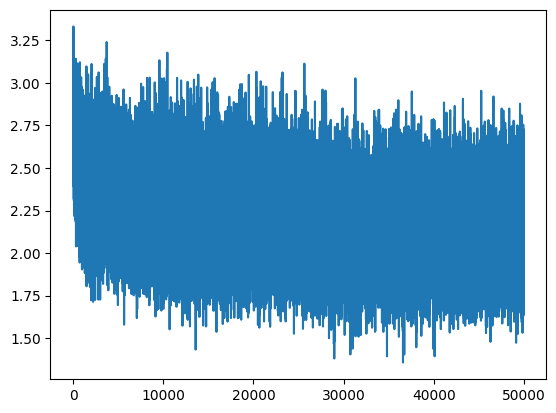

In [11]:
plt.plot(lossi)

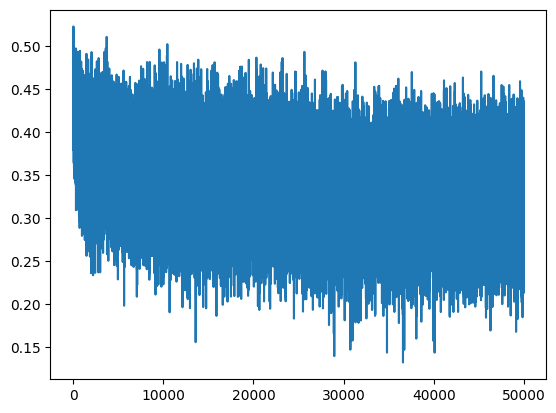

In [12]:
plt.plot(lossilog)

In [13]:
for layer in layers:
    layer.training = False

In [14]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    x = C[x]
    x = x.view(x.shape[0],-1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.1979)
tensor(2.2414)


In [15]:
block_size = 3
for _ in range(20):
    out = []
    context = [0]* block_size
    while True:
        emb = C[torch.tensor([context])]
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim = 1)

        ix = torch.multinomial(probs, num_samples = 1, replacement = True).item()
        # out.append()
        context = context[1:] +[ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))



cassisidijissa.
anzlee.
avweelammnid.
amalida.
aizo.
hunyle.
dodkeyleyla.
tai.
nassaurona.
ferlanna.
julynn.
damel.
jazzi.
silslynn.
cela.
penustina.
zavisgan.
bridn.
shrmo.
kambriggregir.


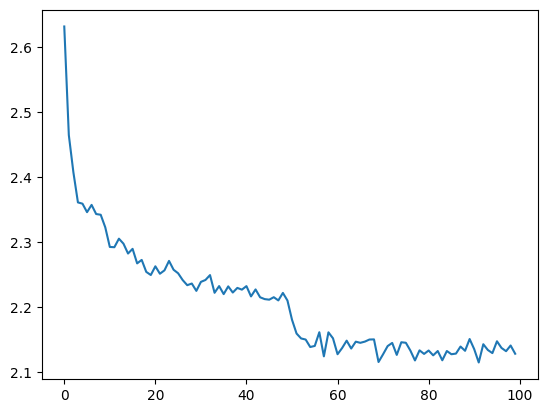

In [16]:
plt.plot(torch.tensor(lossi).view(-1, 500).mean(1))

## Pytorchifying more

In [17]:
class Embedding:
    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(num_embedding, embedding_dim)

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class Flatten:
    def __call__(self, X):
        self.out = (X.view(X.shape[0], -1))
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    



In [18]:
n_embd = 10
hidden_dim = 200
# g = torch.Generator().manual_seed(212)
vocab_size = 27
# C = torch.randn((vocab_size, n_embd))
# layers =[
#     Embedding(vocab_size, n_embd),
#     Flatten(),
#     Linear(n_embd*block_size, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
#     Linear(hidden_dim,vocab_size)
# ]

model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd*block_size, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    Linear(hidden_dim,vocab_size)
])

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  0.5 #1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
len(p)
# p

12097


27

In [19]:
import torch.nn.functional as F
max_steps = 50000
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # emb = C[Xb]
    # x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    logits= model(Xb)
    # for layer in layers:
    #     x = layer(x)

    loss = F.cross_entropy(logits, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())
    break


0 3.4746415615081787


In [20]:
for layer in model.layers:
    layer.training = False

In [21]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(3.4881)
tensor(3.4943)


In [22]:
block_size = 3
for _ in range(20):
    out = []
    context = [0]* block_size
    while True:
        # emb = C[torch.tensor([context])]
        # x = emb.view(emb.shape[0], -1)
        # for layer in layers:
        #     x = layer(x)
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim = 1)

        ix = torch.multinomial(probs, num_samples = 1, replacement = True).item()
        # out.append()
        context = context[1:] +[ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))



pespzxawlhlftvljdcchxjxgeulsaihzzflmudzdwo.
wvcoyzd.
xtpmrgtguhoncvvzajkzgzoccgjtzr.
cnoje.
csnigclgxvlzwduzrprtose.
gzstu.
zsxdgujsfutrxlkflzytlamfhqbqgpztthkovqedlfifnkwswimtkunhmxnxfrpf.
bc.
cnmqwexqxdulatpdqosdfpromwfvmetpprmw.
hmsnbsngusqhrbfyitgmicltumhooeivghskvbahrotofyonqhxahrltpldzunxxluwianxkpnn.
snsbuafxvlo.
yodenebf.
bwkpnnznjolezalozn.
agoavbbhaqoanm.
eohjb.
rvhebs.
aaedponthoonzlbfspctkzxhubvtysubtjoxhor.
afmolijoyhqdchjvmqzsrldltloowvjd.
szckkiaereftlkidtspnpqmiqzmfawbrsqhmdiwykowtfzmnuiebrdusmjxtyvdfbwjtbwiujihqxlraaxdfdmankpodgerqgxxojrlvovmpieiwcgsnlkefrf.
mymvdfsomcdtipe.


In [24]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb 

torch.Size([4, 3])


tensor([[ 0, 10, 15],
        [ 9, 11,  1],
        [ 8, 25,  4],
        [19,  1, 14]])

## Optimising Neural Net

In [25]:
block_size = 8

def build_dataset(words):
    X, Y  = [], []
    for w in words:
        ch = w+'.'
        context = [0] *block_size
        # print(ch)
        for i in ch:
            # print(i)
            ix = stoi[i]
            # print(ix)
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X= torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182538, 8]) torch.Size([182538])
torch.Size([22941, 8]) torch.Size([22941])
torch.Size([22674, 8]) torch.Size([22674])


In [26]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> e
.......e ---> l
......el ---> e
.....ele ---> o
....eleo ---> n
...eleon ---> o
..eleono ---> r
.eleonor ---> e
eleonore ---> .
........ ---> c
.......c ---> a
......ca ---> m
.....cam ---> d
....camd ---> e
...camde ---> n
..camden ---> .
........ ---> x
.......x ---> a
......xa ---> v
.....xav ---> i


In [27]:
n_embd = 10
hidden_dim = 200
# g = torch.Generator().manual_seed(212)
vocab_size = 27
# C = torch.randn((vocab_size, n_embd))
# layers =[
#     Embedding(vocab_size, n_embd),
#     Flatten(),
#     Linear(n_embd*block_size, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
#     Linear(hidden_dim,vocab_size)
# ]

model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(n_embd*block_size, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    Linear(hidden_dim,vocab_size)
])

with torch.no_grad():
    layers[-1].weights *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  0.5 #1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True
len(p)
# p

22097


27

In [29]:
import torch.nn.functional as F
max_steps = 50000
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    # emb = C[Xb]
    # x = emb.view(emb.shape[0], -1)
    # print(x)
    # print(x.shape)
    # print(x.dtype)
    logits= model(Xb)
    # for layer in layers:
    #     x = layer(x)

    loss = F.cross_entropy(logits, Yb)

    for layer in layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())



0 3.447460412979126
5000 2.505319833755493
10000 2.0992980003356934
15000 2.631833791732788
20000 1.8226878643035889
25000 2.1170921325683594
30000 2.0911314487457275
35000 1.9965046644210815
40000 2.145667791366577
45000 2.12699556350708


In [30]:
for layer in model.layers:
    layer.training = False

In [31]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.2596)
tensor(2.3085)


In [32]:
# block_size = 3
for _ in range(20):
    out = []
    context = [0]* block_size
    while True:
        # emb = C[torch.tensor([context])]
        # x = emb.view(emb.shape[0], -1)
        # for layer in layers:
        #     x = layer(x)
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim = 1)

        ix = torch.multinomial(probs, num_samples = 1, replacement = True).item()
        # out.append()
        context = context[1:] +[ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))



bassara.
gustafenna.
rihabdullee.
laditae.
bravengelle.
amarrahir.
zaqshi.
brelynn.
graeles.
brexson.
salilanz.
doviana.
izyanni.
lilrish.
duamirah.
zebrah.
bazeriya.
zulvannell.
bradeyan.
ramver.


## Implementing Wavenet

In [54]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
print(ix)
Xb


torch.Size([4, 8])
tensor([ 69049, 124698, 140392,  31033])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0, 14,  1, 25, 18],
        [ 0,  0,  0,  0,  1, 13,  1, 18],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [42]:
model.layers[0].out.shape

torch.Size([4, 8, 10])

In [43]:
model.layers[1].out.shape

torch.Size([4, 80])

In [44]:
model.layers[2].out.shape

torch.Size([4, 200])

In [46]:
model.layers[5].out.shape

torch.Size([4, 27])

In [47]:
(torch.randn(4,80) @ torch.randn(80, 200) + torch.randn(200)).shape

torch.Size([4, 200])

In [55]:
(torch.randn(4, 4, 20) @ torch.randn(20, 200) + torch.randn(200)).shape

torch.Size([4, 4, 200])

In [ ]:
# (1 2) (3 4) (5 6) (7 8) 
#  (x1    x2)    (x3    x4)
#      (y1           y2)
#             z1

See, above we are processing 2 consecutive input elements nothing at a one go. This is what we wanna achieve for now.
for this (4, 80) can be changed into (4, 4, 20).

So, we are feeding 2 characters at a single neuron.

So, We should shange some things in our linear and flatten layer.

In [14]:
list(range(10))[1::2]

[1, 3, 5, 7, 9]

In [26]:
e = torch.randn(4, 8, 10) # change this to (4, 4, 20)
e.view(4, -1)#it happened previously (4, 80)
exp = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim = 2) # (4, 4, 20)


In [27]:
(e.view(4,4,20) == exp).all()

tensor(True)

In [4]:
block_size = 8

def build_dataset(words):
    X, Y  = [], []
    for w in words:
        ch = w+'.'
        context = [0] *block_size
        # print(ch)
        for i in ch:
            # print(i)
            ix = stoi[i]
            # print(ix)
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]

    X= torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(len(words)*0.8)
n2 = int(len(words)*0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182485, 8]) torch.Size([182485])
torch.Size([22822, 8]) torch.Size([22822])
torch.Size([22846, 8]) torch.Size([22846])


In [9]:
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.fan_in = fan_in
        self.fan_out = fan_out 
        self.isbias = bias
        self.bias = torch.zeros(fan_out) if bias else None
        self.weights = torch.randn(fan_in, fan_out)/ fan_in**0.5
        self.out = None

    def __call__(self, x):
        # print(x.dtype)
        # print(self.weights.dtype)
        self.out = x @ self.weights
        # print(self.bias)
        return self.out + self.bias if self.isbias else self.out

    def parameters(self):
        params = [self.weights] + ([self.bias] if self.bias is not None else [])
        # for i, p in enumerate(params):
            # print(f"Parameter {i}: shape = {tuple(p.shape)}")
        return params
        
        
    

class BatchNorm1D:
    def __init__(self, dim,epsilon = 1e-05, momentum = 0.00001):
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)  
        self.running_std = torch.ones(dim)
        self.eps = epsilon
        self.momentum = momentum

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            if x.ndim ==3:
                dim =(0,1)
            x_mean  = x.mean(dim, keepdim = True)
            x_std = x.var(dim, keepdim = True )
        else:
            x_mean = self.running_mean
            x_std = self.running_std

        self.out = self.gamma * ((x - x_mean)/torch.sqrt(x_std+ self.eps)) + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean  = self.momentum*x_mean  + (1- self.momentum)*self.running_mean
                self.running_std  = self.momentum*x_std  + (1- self.momentum)*self.running_std
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(num_embedding, embedding_dim)

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class Flatten:
    def __init__(self, n):
        self.n = n

    def __call__(self, X):
        B, T, C = X.shape
        X = X.view(B, T//self.n, C*self.n)
        
        if X.shape[1] == 1:
            X = X.squeeze(1)
        self.out = X
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    



In [10]:
n_embd = 10
hidden_dim = 68
vocab_size = 27

model = Sequential([
    Embedding(vocab_size, n_embd),
    Flatten(2),Linear(n_embd*2, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    Flatten(2),Linear(hidden_dim*2, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    Flatten(2),Linear(hidden_dim*2, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    # Flatten(2),Linear(n_embd*2, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),
    # Flatten(2),Linear(hidden_dim*2, hidden_dim, bias = False), BatchNorm1D(hidden_dim), Tanh(),

    Linear(hidden_dim,vocab_size)
])

with torch.no_grad():
    model.layers[-1].weights *= 0.1
    for layer in model.layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *=  0.5 #1

parameters = model.parameters()
# print(type(parameters))
# for p in parameters:
#     print(type(p))
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True
print(len(parameters))

22397
12


In [295]:
for p in parameters[:2]:
    print(p.shape)
    print(p.nelement())

torch.Size([27, 10])
270
torch.Size([20, 68])
1360


In [301]:
p = parameters[0]
print(p.nelement)
print(type(p.nelement))
p.numel()


<built-in method nelement of Tensor object at 0x000002885AD0FCA0>
<class 'builtin_function_or_method'>


270

In [175]:
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)


In [176]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 10)
Flatten : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1D : (4, 4, 68)
Tanh : (4, 4, 68)
Flatten : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1D : (4, 2, 68)
Tanh : (4, 2, 68)
Flatten : (4, 136)
Linear : (4, 68)
BatchNorm1D : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [ ]:
import torch.nn.functional as F
max_steps = 50000
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    logits= model(Xb)
    

    loss = F.cross_entropy(logits, Yb)

    for layer in model.layers:
        layer.out.retain_grad()

    for p in parameters:  
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())


0 3.263643980026245
5000 2.2983686923980713
10000 2.069155216217041
15000 1.982372522354126
20000 1.7873823642730713
25000 1.93794584274292
30000 2.1449317932128906
35000 2.022451162338257
40000 1.7733649015426636
45000 2.695643186569214


In [172]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.0296)
tensor(2.0715)


In [ ]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim = True) # (1, 4, 68)
evar = e.var(0, keepdim = True) # (1, 4, 68)
ehat = (e-emean) / torch.sqrt(evar + 1e-5) #(32, 4, 68) 
ehat.shape
emean = e.mean((0,1), keepdim = True) # (1, 1, 68)
evar = e.var((0,1), keepdim = True) # (1, 1, 68)


What happened was when in 3D and when we are doing BN the previous code collected the mean and var in wrong way that way the calculations were wrong and we were somehow calculating wrong stuffs and emean which needs to be only 68 but it wasn't like that 
. So, we need to

In [278]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [277]:
x = torch.tensor([
  [[ 1.,  2.], [ 3.,  4.], [ 5.,  6.]],
  [[ 7.,  8.], [ 9., 10.], [11., 12.]],
])
print(x.shape)
x.mean(2).shape

torch.Size([2, 3, 2])


torch.Size([2, 3])

In [228]:
x = torch.randn(3000, 20, 5)
torch.mean(x[0][:][0]).shape

torch.Size([])

In [229]:
x.size()

torch.Size([3000, 20, 5])

In [231]:
len(x)

3000

In [234]:
len(x[0])

20

In [244]:
x[2999][19]

tensor([-0.4924,  1.0864, -0.5343,  1.0871, -1.3771])

In [245]:
x[1]

tensor([[ 1.0343,  0.3726, -0.4269,  0.6759,  0.0452],
        [-1.1487, -1.3693,  0.6424, -1.0356,  0.3949],
        [-1.0651, -0.6696,  0.3000,  0.6537, -0.6863],
        [ 0.8568,  0.5778, -1.2874,  0.6152,  0.3237],
        [ 0.2775, -1.1734,  0.4451,  1.6681,  0.2572],
        [-0.1834, -1.2649,  0.3353, -0.0217,  1.2676],
        [-1.0334, -2.0503,  0.5099, -1.4060,  0.7301],
        [ 0.7067,  1.2141,  0.6165,  1.0320,  0.8829],
        [ 0.2190, -0.0117,  0.7516,  1.5374,  0.3615],
        [ 0.3281, -0.6909, -0.8128, -0.4054,  1.1081],
        [-0.2824, -0.1238,  0.6951, -0.9391,  0.9697],
        [-0.8944, -0.8477,  0.3151,  1.1452, -0.7751],
        [-0.3824,  0.0907, -0.0556,  0.8757, -0.5693],
        [-0.6677, -0.6762, -0.7641,  0.7286,  0.1854],
        [-0.1394, -0.3454,  0.2474,  0.0241,  0.6171],
        [ 0.7373, -1.0362,  0.0940,  1.9747, -1.4126],
        [-0.6665,  0.0452, -0.9592, -1.7184,  2.5843],
        [-0.9812,  0.2688,  1.4571, -1.7725,  0.7353],
        [ 

In [272]:
y = torch.randn(3000, 5)


for i in range(3000):
    
    
    for k in range(5):
        sum = 0
        for j in range(20):
            sum += x[i][j][k]
    mean = sum/20
    y[i][k] = mean
    k+=1

In [273]:
y[0]

tensor([ 0.5230,  0.3388, -1.3002,  1.7517,  0.1100])

In [268]:
y = torch.zeros(3000, 5)

for i in range(3000):        # For every loaf (Row)
    for k in range(5):       # For every crumb position (Column)
        total_sum = 0
        for j in range(20):  # For every slice (Depth)
            total_sum += x[i][j][k]
        
        y[i][k] = total_sum / 20

In [267]:
x.mean(1)[0]

tensor([-0.0629,  0.2607,  0.4153, -0.2445,  0.1100])

In [ ]:
x[0][1][0]

tensor(0.1062)

In [259]:
x[0][0][0]

tensor(0.3055)

In [11]:
#After fixing emean, evar bug
import torch.nn.functional as F
max_steps = 50000
batch_size = 32
lossi= []
lossilog = []
for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    logits= model(Xb)
    

    loss = F.cross_entropy(logits, Yb)

    for layer in model.layers:
        layer.out.retain_grad()

    for p in parameters:  
        p.grad = None
    loss.backward()
    lossi.append(loss.item())
    lr = 0.1 if i< 25000 else 0.01
    for p in parameters :
        p.data += -p.grad *lr

    if i%5000 == 0:
        print(i, loss.item())
    
    lossilog.append(loss.log10().item())


0 3.2888450622558594
5000 2.2060017585754395
10000 2.087552547454834
15000 1.9122307300567627
20000 2.0829248428344727
25000 2.3280773162841797
30000 2.2098426818847656
35000 1.8935010433197021
40000 2.226957321166992
45000 1.971985936164856


In [12]:
@torch.no_grad()
def split_loss(split):
    x, y= {
        'train': (Xtr, Ytr),
        'test': (Xtest, Ytest),
        'val': (Xdev, Ydev)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print (loss)

split_loss('train')
split_loss('val')

tensor(2.0047)
tensor(2.0669)


In [1]:
loss

NameError: name 'loss' is not defined